In [3]:
# load the Libraries
pip install prophet

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Import the required labraies

In [5]:
import pandas as pd
from prophet import Prophet

## Load The Data


In [8]:
df = pd.read_csv("Totals.csv")
df.head()

,Date,Subscribers
0,2022-03-05,2
1,2022-03-06,0
2,2022-03-07,0
3,2022-03-08,0
4,2022-03-09,0


In [10]:
# last five data
df.tail()

,Date,Subscribers
1255,2025-08-11,9
1256,2025-08-12,15
1257,2025-08-13,16
1258,2025-08-14,19
1259,2025-08-15,10


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         1260 non-null   object
 1   Subscribers  1260 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 19.8+ KB


In [14]:
df['Date'] = pd.to_datetime(df['Date'])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1260 non-null   datetime64[ns]
 1   Subscribers  1260 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 19.8 KB


## Visualization of the data wrt the nuber of subcribers

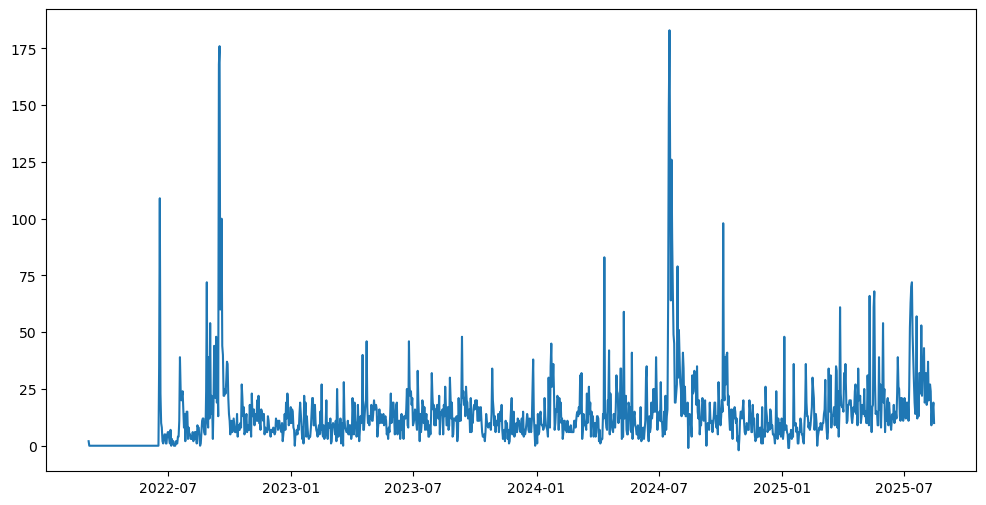

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df['Date'],  df['Subscribers'])
plt.show()

In [23]:
m = Prophet()
df.columns = ['ds', 'y']
model = m.fit(df)

11:59:09 - cmdstanpy - INFO - Chain [1] start processing
11:59:09 - cmdstanpy - INFO - Chain [1] done processing


### Future Predictions 

In [31]:
future_prediction = m.make_future_dataframe(periods=1460) ## 1460 means => 4 year.( 365*4 => 1460)
forcast = m.predict(future_prediction)
forcast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
2715,2029-08-10,33.099239,5.594835,60.843564,11.057521,54.934256,-0.387921,-0.387921,-0.387921,0.007299,0.007299,0.007299,-0.395219,-0.395219,-0.395219,0.0,0.0,0.0,32.711318
2716,2029-08-11,33.108633,3.656093,59.089426,11.037747,54.957685,-0.595168,-0.595168,-0.595168,0.610463,0.610463,0.610463,-1.205631,-1.205631,-1.205631,0.0,0.0,0.0,32.513465
2717,2029-08-12,33.118028,2.935826,60.041345,11.017974,54.987866,-0.687700,-0.687700,-0.687700,1.211090,1.211090,1.211090,-1.898790,-1.898790,-1.898790,0.0,0.0,0.0,32.430327
2718,2029-08-13,33.127422,0.654484,58.927277,10.994525,55.021532,-2.859627,-2.859627,-2.859627,-0.394205,-0.394205,-0.394205,-2.465422,-2.465422,-2.465422,0.0,0.0,0.0,30.267795
2719,2029-08-14,33.136816,1.331774,57.868224,10.964765,55.055199,-3.674881,-3.674881,-3.674881,-0.776340,-0.776340,-0.776340,-2.898541,-2.898541,-2.898541,0.0,0.0,0.0,29.461935


In [32]:
print("four year after my sub.. :", forcast['yhat'].sum())

four year after my sub.. : 55692.34416512553


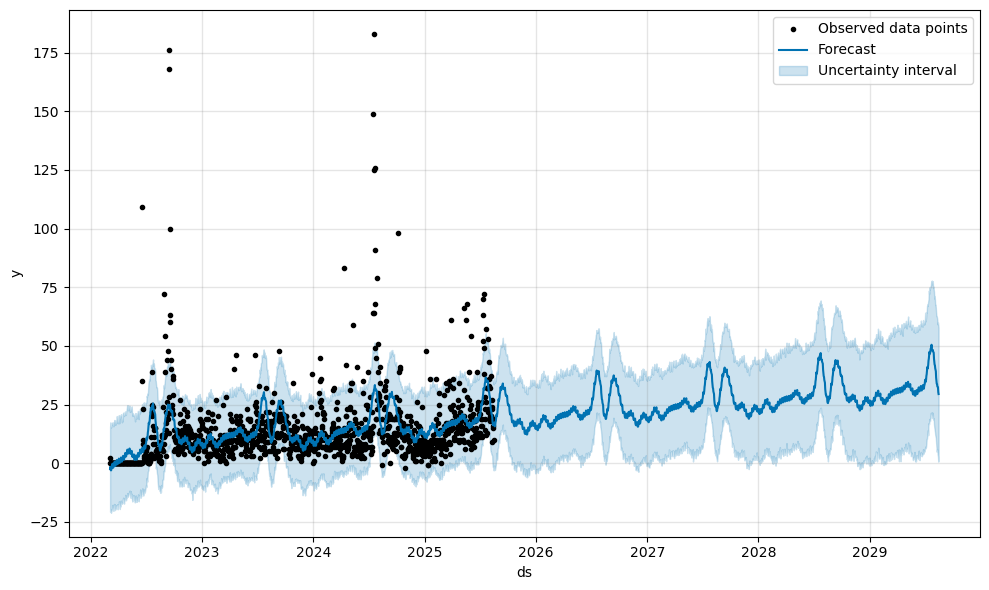

In [36]:
# ploting
feg1 = m.plot(forcast)
plt.legend()
plt.show()

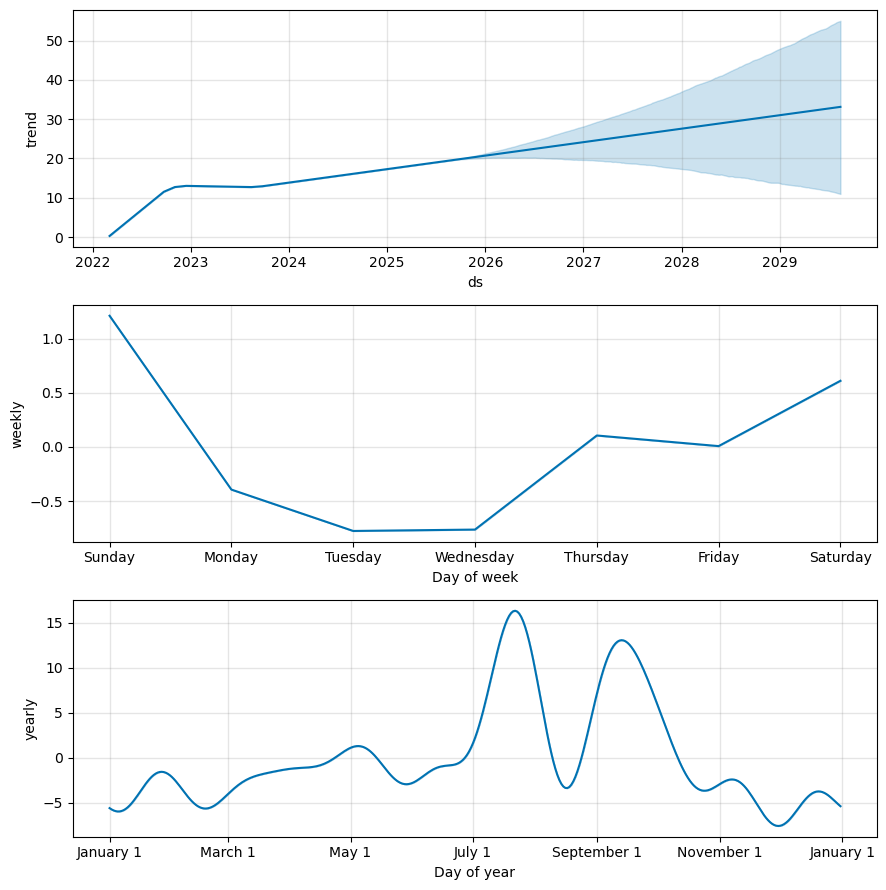

In [37]:
fig2 = m.plot_components(forcast)